In [1]:
print("Hello World")

Hello World


In [2]:
# import required packages for visualizations
import scanpy as sc
import pandas as pd
import numpy as np
import os

In [3]:
# Load the expression matrix where the rows are genes and the columns are cells
dem = pd.read_csv("/data/vangalenlab/das/aml-clonal-dashboard/data/raw/GSM3587923_AML1012-D0.dem.txt", sep ="\t", index_col=0)

# See the shape just to make sure
print(dem.shape)

# See the matrix
print(dem.iloc[:5, :5])

(27899, 1136)
          AML1012-D0_AAAAAGTTACGT  AML1012-D0_AAAACACCAATC  \
Gene                                                         
A1BG                            1                        0   
A1BG-AS1                        0                        0   
A1CF                            0                        0   
A2M                             0                        0   
A2M-AS1                         0                        0   

          AML1012-D0_AAAATAGCCTTT  AML1012-D0_AAACATTAAACG  \
Gene                                                         
A1BG                            0                        0   
A1BG-AS1                        0                        0   
A1CF                            0                        0   
A2M                             0                        0   
A2M-AS1                         0                        0   

          AML1012-D0_AAACCACGTGCN  
Gene                               
A1BG                            0  
A1BG-AS1

First we will load in the cell annotations in order to do annotations on the UMAP or PCA plot later on. We need to transpose the expression data in because AnnData expects a cell X gene matrix; the data that we are given is gene X cell matrix, so transposing the matrix would put it in the right format.

In [4]:
# Load the annotations too
anno = pd.read_csv("/data/vangalenlab/das/aml-clonal-dashboard/data/raw/GSM3587924_AML1012-D0.anno.txt", sep ="\t", index_col=0)

# Transpose the expression data
adata = sc.AnnData(X=dem.T)

# Add the cell annotations
adata.obs = anno.loc[adata.obs_names]

print(adata)

# Show the avaliable annotation columns
print(adata.obs.columns.tolist())

AnnData object with n_obs × n_vars = 1136 × 27899
    obs: 'NumberOfReads', 'AlignedToGenome', 'AlignedToTranscriptome', 'TranscriptomeUMIs', 'NumberOfGenes', 'CyclingScore', 'CyclingBinary', 'MutTranscripts', 'WtTranscripts', 'PredictionRF2', 'PredictionRefined', 'CellType', 'Score_HSC', 'Score_Prog', 'Score_GMP', 'Score_ProMono', 'Score_Mono', 'Score_cDC', 'Score_pDC', 'Score_earlyEry', 'Score_lateEry', 'Score_ProB', 'Score_B', 'Score_Plasma', 'Score_T', 'Score_CTL', 'Score_NK'
['NumberOfReads', 'AlignedToGenome', 'AlignedToTranscriptome', 'TranscriptomeUMIs', 'NumberOfGenes', 'CyclingScore', 'CyclingBinary', 'MutTranscripts', 'WtTranscripts', 'PredictionRF2', 'PredictionRefined', 'CellType', 'Score_HSC', 'Score_Prog', 'Score_GMP', 'Score_ProMono', 'Score_Mono', 'Score_cDC', 'Score_pDC', 'Score_earlyEry', 'Score_lateEry', 'Score_ProB', 'Score_B', 'Score_Plasma', 'Score_T', 'Score_CTL', 'Score_NK']


### QC filtering
We need to perform QC filtering to remvoe 3 types of data: empty droplets (too few genes present), doublets (too many genes present), and dying cells (high mitochondrial content, which indicates cell stress, or inefficient cell capture).

**Filtering barcodes using UMI counts**
UMI counts for each cell barcode can tell us the number of observed transcripts in the droplet. Barcodes that are associated with a high UMI might have droplets with multiple cells or multiplets. Barcodes with an associated low UMI may contain droplets that have ambient RNAs, which don't represent a single cell. Some literature will put arbitrary thresholds to filter the barcodes.

**Filtering cells by number of features**
This is very similar to filtering based on UMI counts. Barcodes with unusally high features might be multiplets and barcodes with low number of features might be droplets with ambient RNAs, but not reall cells. Similarly, literature puts arbitrary thresholds to filter the barcodes based on the number of features.

**Filtering cells by percent of mitochondrial reads**


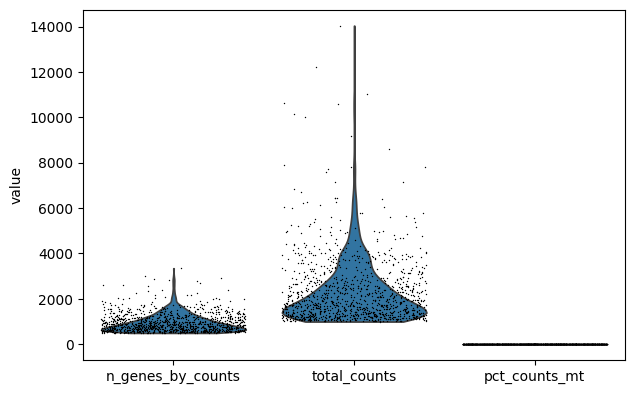

Number of cells after filtering: 1136


In [8]:
# Flag mitochondrial genes, for human genes they start with "MT"
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# Calculate the QC metrics 
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace = True)

# Plot QC violin plots
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter=0.4)

# Filter
sc.pp.filter_cells(adata, min_genes = 200)
sc.pp.filter_genes(adata, min_cells = 3)
adata = adata[adata.obs.pct_counts_mt < 20].copy()

# Print the number of cells afterf filtering
print(f"Number of cells after filtering: {adata.n_obs}")